In [1]:
import numpy as np
import soundfile as sf
from IPython.display import display, Audio
import matplotlib.pyplot as plt
import pyroomacoustics as pra

In [2]:
from Early_IR_Conv import resample, separate_channel, stereo_stack, normalization, estimate_t0, estimate_ER_time, split, energy_ratio, fast_conv, running_convolver_stereo
from Late_reverb_tail import compute_edc_rt60, onepole_lowpass, onepole_highpass, calculate_d, Delay, LPF_Band, LPF_Damping, MAPF, APF, decay, stereo_width, Stereo_FDN_Reverb, mix

In [3]:
signal, signal_sr = sf.read('a-minor-dance-piano~2.wav')
# from https://freesound.org/people/johnthewizar/sounds/238329/

In [4]:
# FOR SHORT IR EXMAPLE
ir, ir_sr =  sf.read('BRIR_R09_C1_E0_A0.wav')
#ir, ir_sr = sf.read('Produktionsstudio_KU100_004Yaw_06_RearRight.wav')
# from https://www.production-expert.com/production-expert-1/free-impulse-responses-excellent-for-sound-design-and-post-production

In [5]:
# FOR MID IR EXAMPLE
#ir, ir_sr = sf.read('02b-TYS-ST450-BInaural-BURST.wav')

In [6]:
# FOR LONG IR EXAMPLE
#ir, ir_sr =  sf.read('base_44_hemiaux_center_sck_023.wav')
#ir, ir_sr = sf.read('base_44_hemiaux_back_dpa_022.wav')
# from https://iem.kug.ac.at/en/forschung/ueberblick/forschungsprojekte/irdb

In [7]:
# define system's sample rate and resample
Fs = 44100
signal_re = resample(signal_sr, Fs, signal)
ir_re = resample(ir_sr, Fs, ir)

In [8]:
Audio(signal_re, rate=Fs)

In [9]:
Audio(ir_re.T, rate=Fs)

In [10]:
# separate ir's two channels
ir_re_L, ir_re_R = separate_channel(ir_re.T)

In [11]:
# estimate arrival time of direct sound of ir
direct_t_L = estimate_t0(ir_re_L, Fs, win=32, noise_ms=150.0, k=10.0)
direct_t_R = estimate_t0(ir_re_R, Fs, win=32, noise_ms=150.0, k=10.0)
print(direct_t_L, direct_t_R)

0.0008616780045351474 0.0008616780045351474


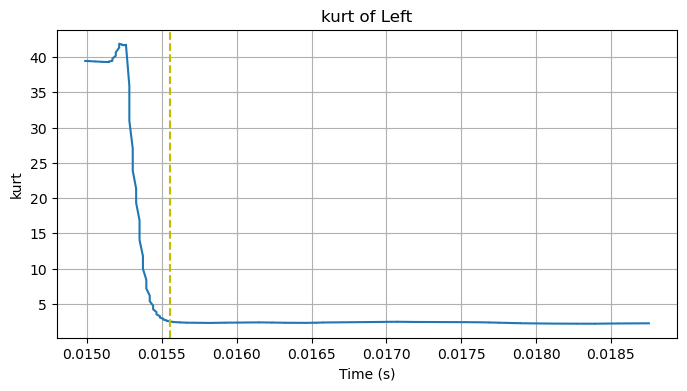

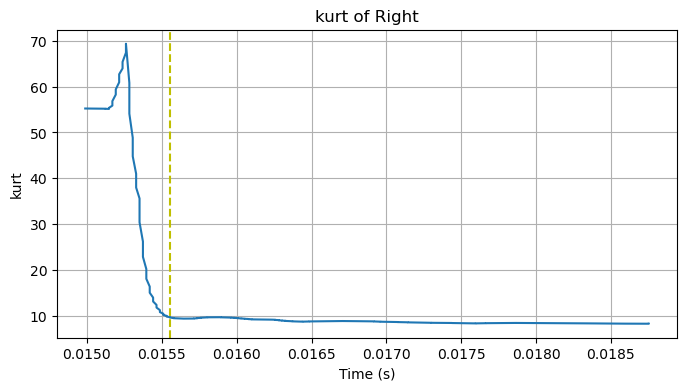

In [12]:
# estimate end time of early reflection
t_L, kurt_L, early_t_L, split_t_L = estimate_ER_time(ir_re_L, Fs, direct_t_L, win_ms=30, hop_ms=3, alpha=0.2)
t_R, kurt_R, early_t_R, split_t_R = estimate_ER_time(ir_re_R, Fs, direct_t_R, win_ms=30, hop_ms=3, alpha=0.2)

plt.figure(figsize=(8,4))
plt.plot(t_L, kurt_L)
plt.axvline(early_t_L, color='y', linestyle='--', label='E/Early Split')
plt.title("kurt of Left")
plt.xlabel("Time (s)")
plt.ylabel("kurt")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(t_R, kurt_R)
plt.axvline(early_t_R, color='y', linestyle='--', label='E/Early Split')
plt.title("kurt of Right")
plt.xlabel("Time (s)")
plt.ylabel("kurt")
plt.grid(True)
plt.show()

In [13]:
# split full IR into ir_early(contains direct sound) and ir_late, using overlap and linear crossfade method
ir_early_L, ir_late_L = split(direct_t_L, split_t_L, 0.003, ir_re_L, Fs)
ir_early_R, ir_late_R = split(direct_t_R, split_t_R, 0.003, ir_re_R, Fs)

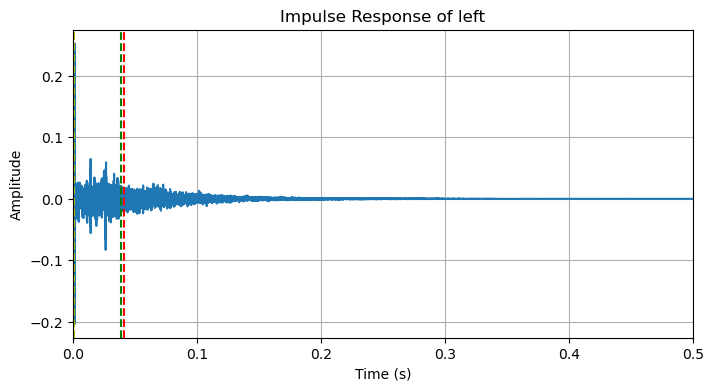

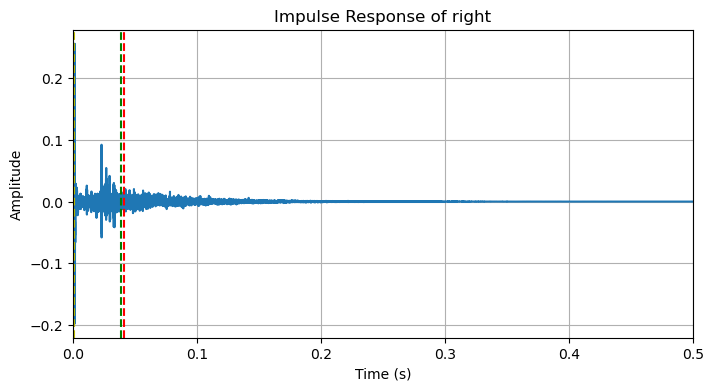

In [14]:
# create timeline
t = np.arange(len(ir_re)) / Fs

plt.figure(figsize=(8,4))
plt.plot(t, ir_re_L)
plt.axvline(direct_t_L, color='y', linestyle='--', label='Direct/Early Split')
plt.axvline(split_t_L, color='r', linestyle='--', label='Early/Late Split')
plt.axvline(split_t_L-0.003, color='g', linestyle='--', label='Late_fadeIn')
plt.title("Impulse Response of left")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0.0, 0.5)
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(t, ir_re_R)
plt.axvline(direct_t_R, color='y', linestyle='--', label='Direct/Early Split')
plt.axvline(split_t_R, color='r', linestyle='--', label='Early/Late Split')
plt.axvline(split_t_R-0.003, color='g', linestyle='--', label='Late_fadeIn')
plt.title("Impulse Response of right")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0.0, 0.5)
plt.grid(True)
plt.show()

In [15]:
ratio_L = energy_ratio(ir_early_L, ir_late_L)
ratio_R = energy_ratio(ir_early_R, ir_late_R)
print(ratio_L, ratio_R)

0.8190543110927029 0.8799118367859237


In [16]:
# Latency (s) for block_size 256
block_size = 256
latency = block_size / Fs
latency

0.005804988662131519

In [17]:
# fast conv audio with early impulse response
signal_early, block_time_early = running_convolver_stereo(signal_re, ir_early_L, ir_early_R, block_size)

running conv took 0.522320 seconds total.
average time per block: 0.000424 seconds


In [18]:
# fast conv audio with full impulse response.
signal_full, block_time_full = running_convolver_stereo(signal_re, ir_re_L, ir_re_R, block_size)

running conv took 24.904189 seconds total.
average time per block: 0.020198 seconds


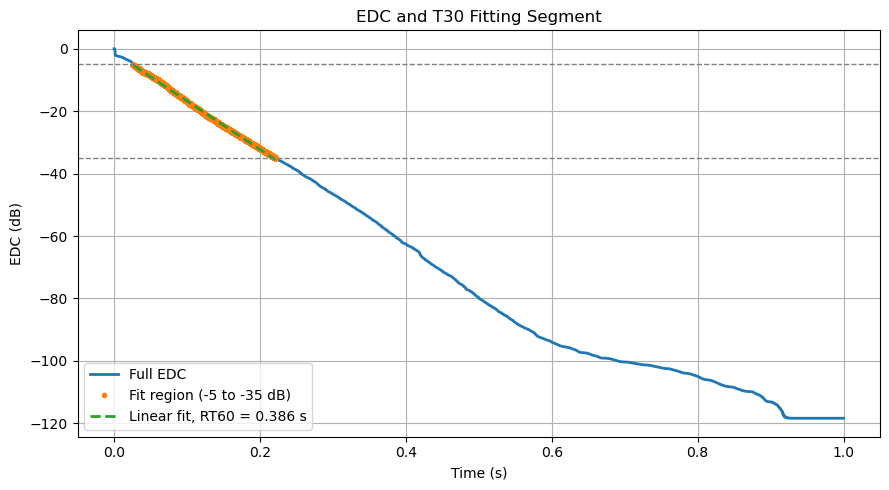

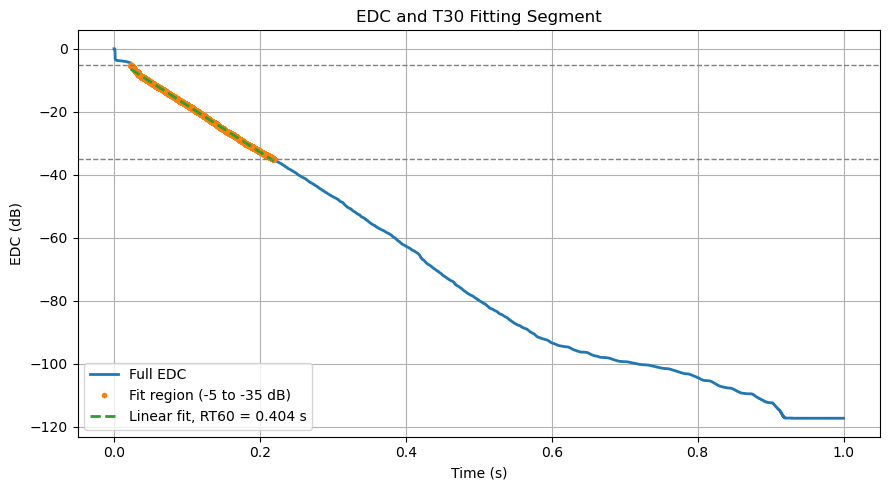

In [19]:
# estimate rt60 for late ir using ISO T20 rule and Schroeder's method
esti_rt60_L, edc_db_L = compute_edc_rt60(ir_re_L, Fs, fit_plt=True)
esti_rt60_R, edc_db_R = compute_edc_rt60(ir_re_R, Fs, fit_plt=True)

In [20]:
# for comparison
real_rt60_L = pra.experimental.measure_rt60(ir_re_L, Fs)
real_rt60_R = pra.experimental.measure_rt60(ir_re_R, Fs)
print(real_rt60_L, real_rt60_R)

# calculate the estimation error
error_L = abs(real_rt60_L - esti_rt60_L) / real_rt60_L
error_R = abs(real_rt60_R - esti_rt60_R) / real_rt60_R
error = (error_L + error_R) / 2
print(error)

0.390907029478458 0.39365079365079364
0.01896459697070369


Error Analysis: For **multi-slope decay curves**, the linear recursive method will fail. In this work, RT60 is still estimated using the conventional T30 definition, while acknowledging that the result may not fully represent the late reverberation behavior. For more precise estimation, we need to use more complex method in the future.

In [21]:
# low pass ir_late at fc=1000
ir_late_low_L = onepole_lowpass(ir_late_L, 1000, Fs)
ir_late_low_R = onepole_lowpass(ir_late_R, 1000, Fs)
# high pass ir_late at fc=2000
ir_late_high_L = onepole_highpass(ir_late_L, 2000, Fs)
ir_late_high_R = onepole_highpass(ir_late_R, 2000, Fs)

In [22]:
# calculate damping for LPF in FDN by difference between rt60 of diff freq bands
esti_rt60_low_L, edc_db_low_L = compute_edc_rt60(ir_late_low_L, Fs, fit_plt=False)
esti_rt60_low_R, edc_db_low_R = compute_edc_rt60(ir_late_low_R, Fs, fit_plt=False)
esti_rt60_high_L, edc_db_high_L = compute_edc_rt60(ir_late_high_L, Fs, fit_plt=False)
esti_rt60_high_R, edc_db_high_R = compute_edc_rt60(ir_late_high_R, Fs, fit_plt=False)
d_L = calculate_d(1000, 2000, 0.2, 0.8, ir_late_L, Fs, esti_rt60_low_L, esti_rt60_high_L)
d_R = calculate_d(1000, 2000, 0.2, 0.8, ir_late_R, Fs, esti_rt60_low_R, esti_rt60_high_R)

In [23]:
width = stereo_width(ir_late_L, ir_late_R, eps=1e-12)
width

np.float64(0.3337445150813137)

In [24]:
Reverb = Stereo_FDN_Reverb(Fs, d_L, d_R, esti_rt60_L, esti_rt60_R, width)
tail_L, tail_R, block_time_late = Reverb.tail_block_processing(signal_re, block_size)
signal_tail = normalization(stereo_stack(tail_L, tail_R))

Tail processing took 6.003514 seconds total.
Average time per block: 0.004267 seconds


In [25]:
Audio(signal_tail, rate=Fs)

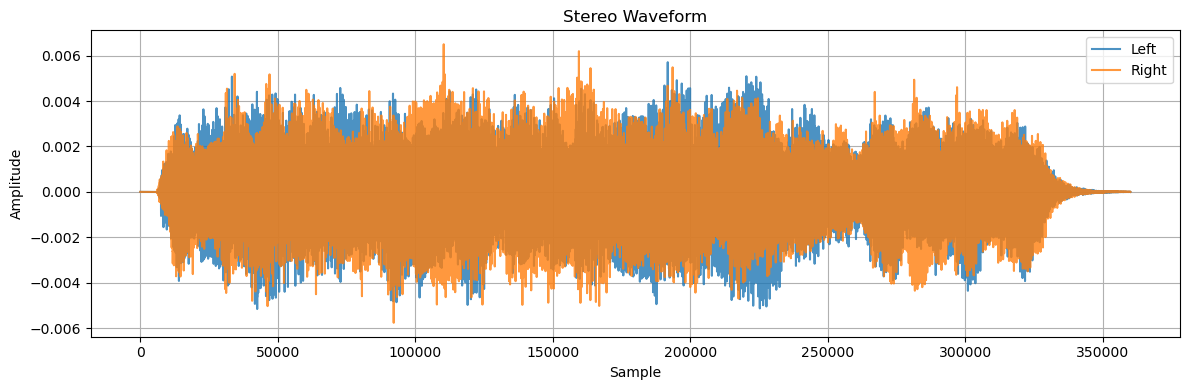

In [26]:
plt.figure(figsize=(12, 4))
plt.plot(tail_L, label="Left", alpha=0.8)
plt.plot(tail_R, label="Right", alpha=0.8)
plt.title("Stereo Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
# mixing early reflection and reverb tail
final_out = mix(direct_t_L, direct_t_R, signal_early, signal_tail, Fs, ratio_L, ratio_R)
Audio(final_out, rate=Fs)

[np.float64(0.007860003335389085), np.float64(0.003358664294575183)] [np.float64(0.009442825630801226), np.float64(0.0027581261653999065)]


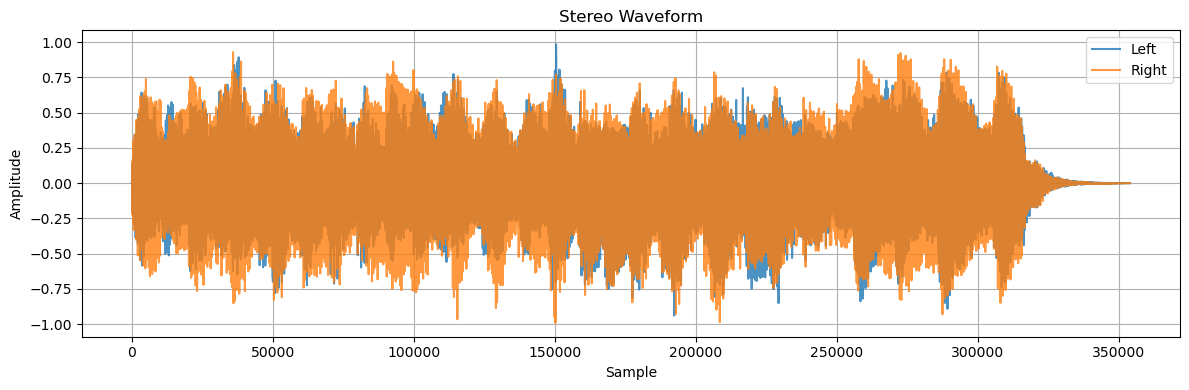

In [28]:
plt.figure(figsize=(12, 4))
plt.plot(final_out[0], label="Left", alpha=0.8)
plt.plot(final_out[1], label="Right", alpha=0.8)
plt.title("Stereo Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
#sf.write("sig_hybird_reverb_longback.wav", final_out.T, Fs)

In [30]:
Audio(signal_early, rate=Fs)

In [31]:
Audio(signal_full, rate=Fs)

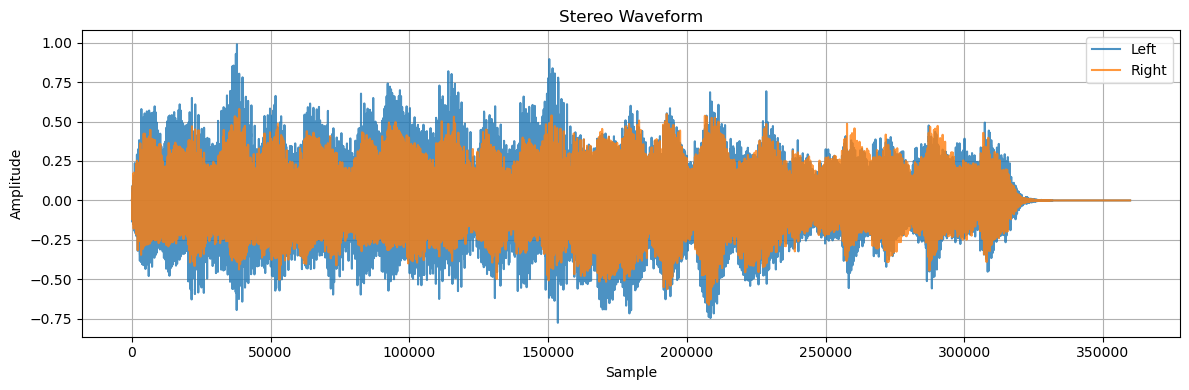

In [32]:
plt.figure(figsize=(12, 4))
plt.plot(signal_full[0], label="Left", alpha=0.8)
plt.plot(signal_full[1], label="Right", alpha=0.8)
plt.title("Stereo Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
#sf.write("sig_full_conv_longback.wav", signal_full.T, Fs)

In [34]:
block_time_split = block_time_early + block_time_late
block_time_split

0.004690506875698557

In [35]:
block_time_full

0.02019804469570336

In [36]:
latency

0.005804988662131519

In [37]:
speed_up = 1 / ((block_time_split) / block_time_full)
speed_up

4.306153946889859